['squad_value_home', 'squad_value_away', 'squad_value_diff', 'home_avg_market_value', 'away_avg_market_value', 'foreign_ratio_home', 'foreign_ratio_away', 'foreign_ratio_diff', 'avg_age_home', 'avg_age_away', 'avg_age_diff', 'win_rate_last5_home', 'win_rate_last5_away', 'win_rate_last5_diff', 'h2h_win_rate_home', 'goal_diff_pg_home', 'goal_diff_pg_away', 'goal_diff_pg_diff', 'h2h_goal_diff', 'season_ppg_home', 'season_ppg_away', 'season_ppg_diff']


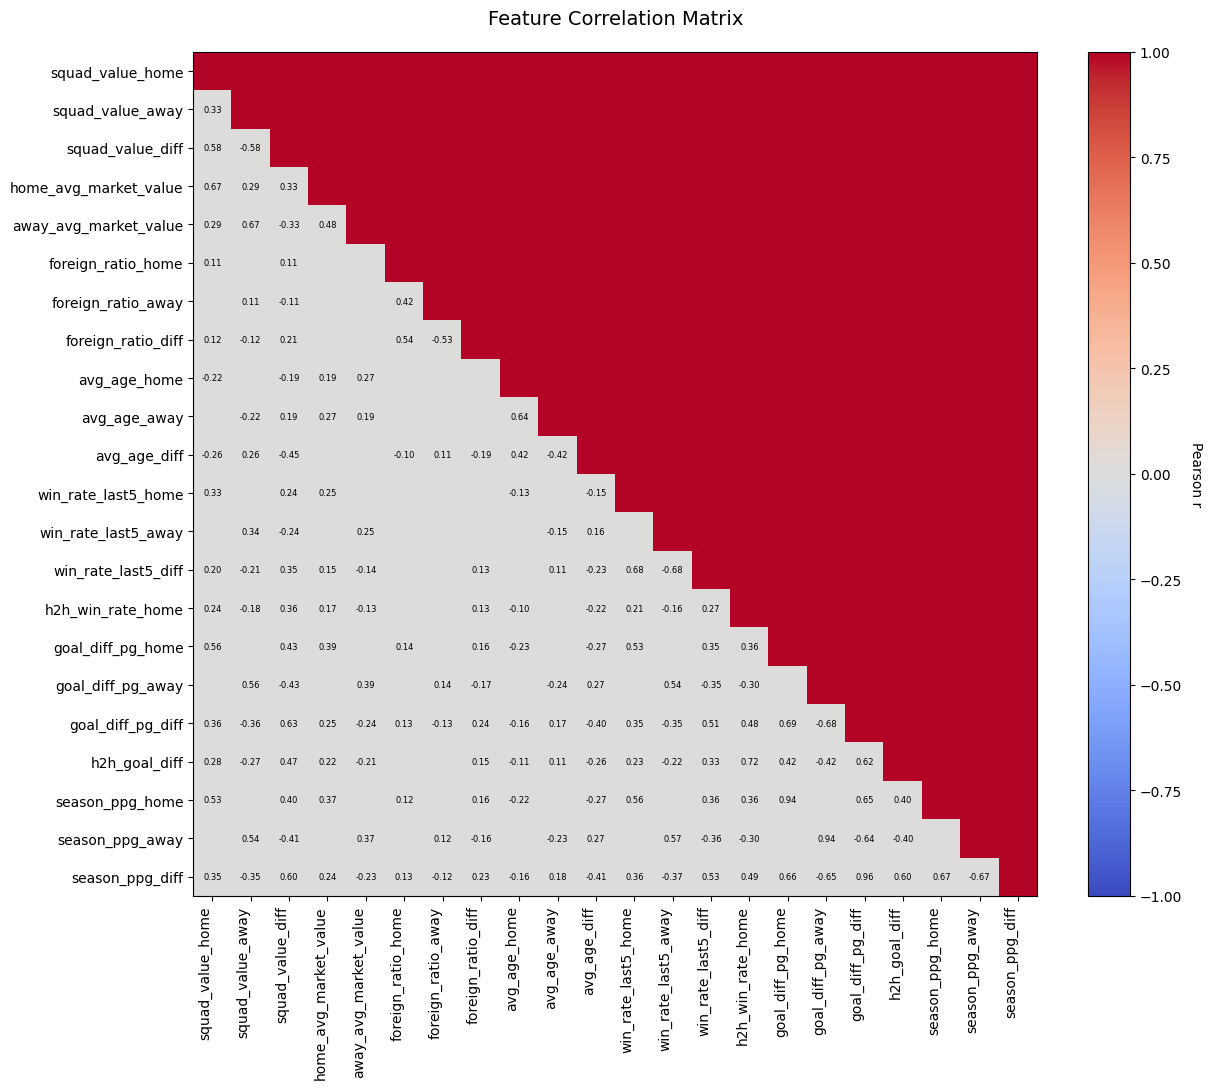

In [ ]:
# corr matrix
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Load your merged features + “result” (as strings):
df_feats = pd.read_csv("match_features_merged.csv")
df_labels = pd.read_csv("../cleaned_data/final_dataset.csv",
                        usecols=["game_id", "result"])
merged = df_feats.merge(df_labels, on="game_id")

# 2. Convert “result” → numeric code (Home Win=0, Draw=1, Away Win=2)
merged["result_code"] = merged["result"].map({
    "Home Win": 0,
    "Draw":     1,
    "Away Win": 2
})

# 3. Build a purely‐numeric DataFrame (drop game_id, drop the original string “result”)
num = (
    merged
    .drop(columns=["game_id", "result"])
    .select_dtypes(include="number")
)

# 3a. Drop all “*_missing” flags
missing_cols = [c for c in num.columns if c.endswith(("_missing", "_flag"))]
missing_cols.append("league_tier")  # same league...
num = num.drop(columns=missing_cols)

keep = sum([
    ['squad_value_home', 'squad_value_away', 'squad_value_diff',
     'home_avg_market_value', 'away_avg_market_value'],
    ['foreign_ratio_home', 'foreign_ratio_away', 'foreign_ratio_diff'],
    ['avg_age_home', 'avg_age_away', 'avg_age_diff'],
    ['win_rate_last5_home', 'win_rate_last5_away', 'win_rate_last5_diff',
     'h2h_win_rate_home'],
    ['goal_diff_pg_home', 'goal_diff_pg_away', 'goal_diff_pg_diff',
     'h2h_goal_diff'],
    ['season_ppg_home', 'season_ppg_away', 'season_ppg_diff'],
], [])

num = num[keep]

# show the whole list
print(num.columns.tolist())

# 5. Compute Pearson‐r matrix
corr = num.corr(method="pearson")

# 6. Mask out the upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

# 7. Plot
fig, ax = plt.subplots(figsize=(14, 11))
cmap = plt.get_cmap("coolwarm")

# Only show lower triangle:
corr_masked = np.ma.masked_where(mask, corr.to_numpy())
im = ax.imshow(corr_masked, cmap=cmap, vmin=-1, vmax=1)


# Configure ticks
labels = corr.columns.tolist()
n = len(labels)
ax.set_xticks(np.arange(n))
ax.set_yticks(np.arange(n))
__FONTSIZE = 10
ax.set_xticklabels(labels, rotation=90, ha="right", fontsize=__FONTSIZE)
ax.set_yticklabels(labels, fontsize=__FONTSIZE)

# Add correlation‐value text for |r| ≥ 0.1
for i in range(n):
    for j in range(i):
        r = corr.iat[i, j]
        if abs(r) >= 0.10:
            ax.text(j, i, f"{r:.2f}",
                    ha="center", va="center",
                    fontsize=6, color="black")

# Colorbar
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.ax.set_ylabel("Pearson r", rotation=270, labelpad=15)

ax.set_title("Feature Correlation Matrix",
             pad=20, fontsize=14)
fig.tight_layout()
plt.show()

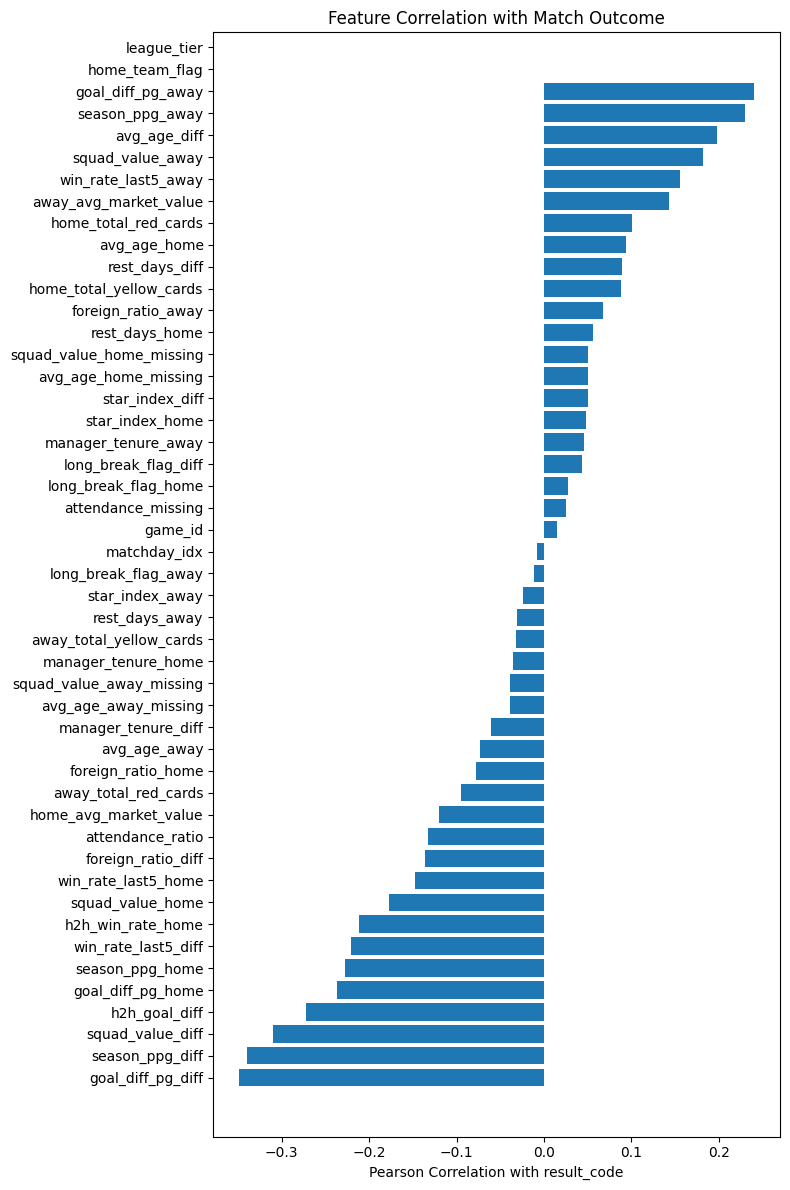

In [18]:
# bar graph

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Load merged features and final dataset to get result_code
features_df = pd.read_csv("match_features_merged.csv")
final_df = pd.read_csv("../cleaned_data/final_dataset.csv")

# Map textual outcomes to numeric codes if needed
final_df["result_code"] = final_df["result"].map(
    {"Home Win": 0, "Draw": 1, "Away Win": 2})

# Merge on game_id so each row in features_df has its result_code
df = features_df.merge(
    final_df[["game_id", "result_code"]], on="game_id", how="left")

# 2. Compute Pearson correlation between every numeric feature and result_code
numeric_cols = df.select_dtypes(include=["number"]).columns
corr_with_result = df[numeric_cols].corr()["result_code"].drop("result_code")
corr_sorted = corr_with_result.sort_values(ascending=True)

# 3. Plot a horizontal bar chart
plt.figure(figsize=(8, 12))
plt.barh(corr_sorted.index, corr_sorted.values)
plt.xlabel("Pearson Correlation with result_code")
plt.title("Feature Correlation with Match Outcome")
plt.tight_layout()
plt.show()